# Music Genre Classification from Lyrics
**Course:** Deep Learning — University of Bologna  
**Student:** Chiara Sivieri

This notebook explores music genre classification from song lyrics, comparing two approaches:

1. **Baseline** — TF-IDF vectorization + MLP classifier (scikit-learn)
2. **Advanced** — Fine-tuning of DistilBERT for sequence classification (HuggingFace Transformers)

The dataset is [Scrapped Lyrics from 6 Genres](https://www.kaggle.com/datasets/neisse/scrapped-lyrics-from-6-genres) (Kaggle). We filter to English lyrics only and keep the 5 most represented genres.

## 1. Setup

In [2]:
!pip3 install -q kaggle transformers accelerate scikit-learn pandas numpy matplotlib seaborn tqdm

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [4]:
import os, json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## 2. Data Loading

We download the dataset from Kaggle using the API. The dataset consists of two CSV files:
- `artists-data.csv` — artist metadata including genre labels
- `lyrics-data.csv` — song lyrics linked to artists

We merge them on the artist link column.

In [5]:
KAGGLE_USERNAME = "chiarasivieri"
KAGGLE_KEY      = "KGAT_c3ddfa1b1fe70ae1547eedebdadcfcde"

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
with open(os.path.join(kaggle_dir, "kaggle.json"), "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)

!kaggle datasets download -d neisse/scrapped-lyrics-from-6-genres -p . --unzip -q
print("Downloaded:", [f for f in os.listdir(".") if f.endswith(".csv")])

zsh:1: command not found: kaggle
Downloaded: ['artists-data.csv', 'lyrics-data.csv']


In [6]:
artists = pd.read_csv("artists-data.csv")
lyrics  = pd.read_csv("lyrics-data.csv")

df_raw = lyrics.merge(artists[["Link", "Genres"]], left_on="ALink", right_on="Link", how="left")
df_raw = df_raw[["Lyric", "Genres", "language"]].rename(columns={"Lyric": "lyrics", "Genres": "genre"})

print(f"Raw shape: {df_raw.shape}")
print(df_raw.head(3))

Raw shape: (379931, 3)
                                              lyrics                genre  \
0  Tudo o que eu quero nessa vida,\nToda vida, é\...  Pop; Axé; Romântico   
1  Meu coração\nSem direção\nVoando só por voar\n...  Pop; Axé; Romântico   
2  É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...  Pop; Axé; Romântico   

  language  
0       pt  
1       pt  
2       pt  


## 3. Preprocessing

We apply the following filters and transformations:

- Keep only **English** lyrics (`language == 'en'`)
- Take the **primary genre** when multiple are listed (semicolon-separated)
- Keep only the **top 5 genres** by frequency to ensure class balance
- Clean the text: remove structural tags (e.g. `[Chorus]`), non-alphabetic characters, and extra whitespace

In [7]:
# Filter English, drop nulls and empty strings
df = df_raw[df_raw["language"] == "en"].drop(columns=["language"]).copy()
df = df.dropna()
df = df[(df["lyrics"].str.strip() != "") & (df["genre"].str.strip() != "")]
df = df.reset_index(drop=True)

# Primary genre only
df["genre"] = df["genre"].str.split(";").str[0].str.strip()

# Top 5 genres
genre_counts = df["genre"].value_counts()
TOP_GENRES = genre_counts.head(5).index.tolist()
df = df[df["genre"].isin(TOP_GENRES)].reset_index(drop=True)

print(f"Shape after filtering: {df.shape}")
print(f"Genres: {TOP_GENRES}")

Shape after filtering: (75019, 2)
Genres: ['Rock', 'Pop', 'Heavy Metal', 'Indie', 'Rap']


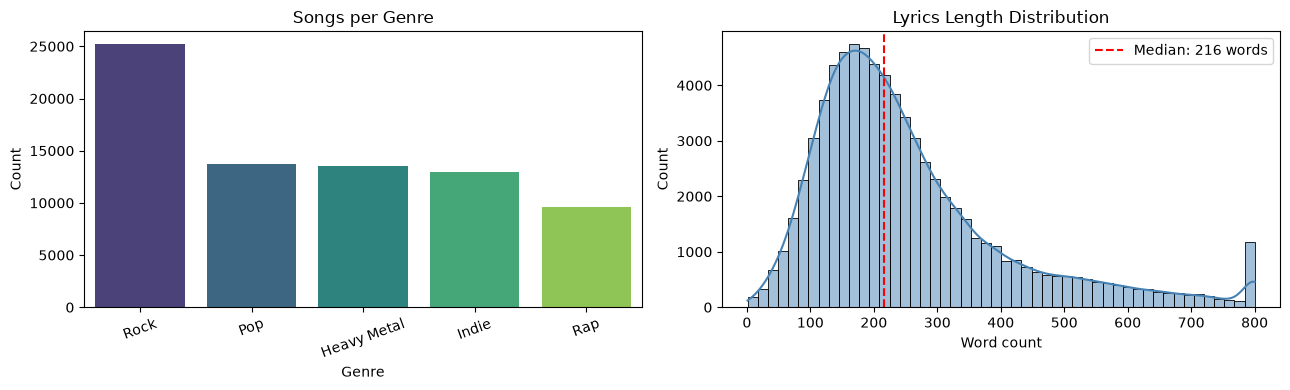

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df["genre"].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette="viridis", ax=axes[0])
axes[0].set(title="Songs per Genre", xlabel="Genre", ylabel="Count")
axes[0].tick_params(axis="x", rotation=20)

df["n_words"] = df["lyrics"].str.split().str.len()
sns.histplot(df["n_words"].clip(upper=800), bins=50, kde=True, color="steelblue", ax=axes[1])
axes[1].axvline(df["n_words"].median(), color="red", linestyle="--",
                label=f"Median: {df['n_words'].median():.0f} words")
axes[1].set(title="Lyrics Length Distribution", xlabel="Word count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
def clean_lyrics(text: str) -> str:
    """Remove structural tags, non-alphabetic characters, and normalize whitespace."""
    text = re.sub(r"\[.*?\]", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["lyrics"].apply(clean_lyrics)
df = df[df["clean"].str.strip() != ""].reset_index(drop=True)

print(f"Final shape: {df.shape}")
print(f"\nBefore: {df['lyrics'].iloc[0][:150]}")
print(f"\nAfter:  {df['clean'].iloc[0][:150]}")

Final shape: (74983, 4)

Before: I feel so unsure
As I take your hand and lead you to the dance floor
As the music dies, something in your eyes
Calls to mind a silver screen
And all t

After:  i feel so unsure as i take your hand and lead you to the dance floor as the music dies something in your eyes calls to mind a silver screen and all th


## 4. Train / Validation / Test Split

We encode the genre labels with `LabelEncoder` and split with stratification to preserve class proportions:

- **Train:** 70%  
- **Validation:** 15%  
- **Test:** 15%

In [10]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["genre"])
NUM_CLASSES = len(le.classes_)

print(f"Classes ({NUM_CLASSES}): {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df["clean"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Classes (5): {'Heavy Metal': np.int64(0), 'Indie': np.int64(1), 'Pop': np.int64(2), 'Rap': np.int64(3), 'Rock': np.int64(4)}
Train: 52488 | Val: 11247 | Test: 11248


## 5. Baseline: TF-IDF + MLP

The baseline uses a classic NLP pipeline:

- **TF-IDF** with unigrams and bigrams (20,000 features, sublinear TF scaling)
- **MLP** with two hidden layers (512 → 256), ReLU activations, and built-in early stopping

In [11]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation="relu",
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
    verbose=True
)
mlp.fit(X_train_tfidf, y_train)

TF-IDF matrix shape: (52488, 20000)
Iteration 1, loss = 0.97005120
Validation score: 0.641456
Iteration 2, loss = 0.58976722
Validation score: 0.622404
Iteration 3, loss = 0.29893333
Validation score: 0.605068
Iteration 4, loss = 0.10198113
Validation score: 0.611355
Iteration 5, loss = 0.05997179
Validation score: 0.609449
Iteration 6, loss = 0.04592529
Validation score: 0.608687
Iteration 7, loss = 0.03836053
Validation score: 0.610402
Iteration 8, loss = 0.03006047
Validation score: 0.604306
Iteration 9, loss = 0.02625316
Validation score: 0.608116
Iteration 10, loss = 0.02235603
Validation score: 0.601638
Iteration 11, loss = 0.01930325
Validation score: 0.608116
Iteration 12, loss = 0.01760643
Validation score: 0.599733
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(512, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init:

[MLP] Val accuracy:    0.6412
[MLP] Val F1 weighted: 0.6370

              precision    recall  f1-score   support

 Heavy Metal       0.72      0.75      0.74      2023
       Indie       0.53      0.42      0.47      1946
         Pop       0.62      0.53      0.57      2064
         Rap       0.87      0.89      0.88      1439
        Rock       0.57      0.66      0.61      3775

    accuracy                           0.64     11247
   macro avg       0.66      0.65      0.65     11247
weighted avg       0.64      0.64      0.64     11247



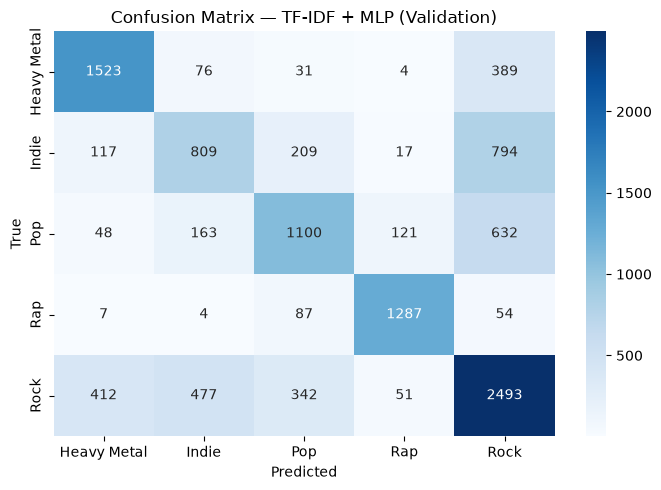

In [12]:
y_val_pred_mlp  = mlp.predict(X_val_tfidf)
y_val_proba_mlp = mlp.predict_proba(X_val_tfidf)

print(f"[MLP] Val accuracy:    {accuracy_score(y_val, y_val_pred_mlp):.4f}")
print(f"[MLP] Val F1 weighted: {f1_score(y_val, y_val_pred_mlp, average='weighted'):.4f}")
print()
print(classification_report(y_val, y_val_pred_mlp, target_names=le.classes_))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred_mlp), annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — TF-IDF + MLP (Validation)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 6. Advanced Model: DistilBERT Fine-tuning

We fine-tune [DistilBERT-base-uncased](https://huggingface.co/distilbert-base-uncased), a distilled version of BERT that is ~40% smaller and ~60% faster while retaining ~97% of BERT's performance on GLUE.

Key design choices:
- **MAX_LEN = 256** tokens — covers the median lyrics length without excessive padding
- **BATCH_SIZE = 32** — fits in GPU memory with fp16 enabled
- **Mixed precision (fp16)** via `torch.cuda.amp` — roughly 2x speedup on NVIDIA GPUs
- **Linear schedule with warmup** (10% of total steps) — standard for BERT fine-tuning
- **Early stopping** with patience = 2 on validation loss

In [17]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 256
BATCH_SIZE = 32

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")


class LyricsDataset(Dataset):
    """PyTorch Dataset with on-the-fly tokenization."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(
    LyricsDataset(X_train, y_train, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(
    LyricsDataset(X_val, y_val, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(
    LyricsDataset(X_test, y_test, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Tokenizer loaded.
Batches — Train: 1641 | Val: 352 | Test: 352


In [18]:
NUM_EPOCHS = 4
LR         = 2e-5

model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES)
model = model.to(device)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11501.01it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 66,957,317
Total steps: 6564 | Warmup: 656


In [19]:
def run_epoch(model, loader, optimizer=None, scheduler=None, scaler=None):
    """One epoch of training or evaluation.
    Pass optimizer=None to run in eval mode with no gradient updates.
    """
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = correct = total = 0
    all_preds, all_probs, all_labels = [], [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, leave=False):
            ids    = batch["input_ids"].to(device, non_blocking=True)
            mask   = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            if training:
                optimizer.zero_grad()
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    out  = model(input_ids=ids, attention_mask=mask, labels=labels)
                    loss = out.loss
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
            else:
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    out  = model(input_ids=ids, attention_mask=mask, labels=labels)
                    loss = out.loss

            probs = torch.softmax(out.logits.float(), dim=-1)
            preds = probs.argmax(dim=-1)

            total_loss += loss.item() * labels.size(0)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().detach().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_labels)
    )

In [20]:
PATIENCE       = 2
best_val_loss  = float("inf")
patience_count = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{NUM_EPOCHS}")

    tr_loss, tr_acc, *_ = run_epoch(model, train_loader, optimizer, scheduler, scaler)
    vl_loss, vl_acc, *_ = run_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"  train  loss {tr_loss:.4f}  acc {tr_acc:.4f}")
    print(f"  val    loss {vl_loss:.4f}  acc {vl_acc:.4f}")

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        patience_count = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("  checkpoint saved")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print("  early stopping")
            break

print("Training complete.")

Epoch 1/4


KeyboardInterrupt: 

## 7. Training Curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs, history["train_loss"], marker="o", label="Train")
ax1.plot(epochs, history["val_loss"],   marker="o", label="Val")
ax1.set(title="Loss per Epoch", xlabel="Epoch", ylabel="Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.plot(epochs, history["train_acc"], marker="o", label="Train")
ax2.plot(epochs, history["val_acc"],   marker="o", label="Val")
ax2.set(title="Accuracy per Epoch", xlabel="Epoch", ylabel="Accuracy")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("DistilBERT Fine-tuning Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

We load the best checkpoint (lowest validation loss) and evaluate both models on the held-out test set.

Metrics reported:
- **Accuracy**
- **F1 macro** — unweighted mean across classes, sensitive to class imbalance
- **F1 weighted** — weighted by class support
- **ROC-AUC OvR** — one-vs-rest macro-averaged AUC

In [ ]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))

_, _, bert_pred, bert_proba, bert_true = run_epoch(model, test_loader)
mlp_pred  = mlp.predict(X_test_tfidf)
mlp_proba = mlp.predict_proba(X_test_tfidf)


def print_metrics(y_true, y_pred, y_proba, name):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average="macro")
    f1_wt  = f1_score(y_true, y_pred, average="weighted")
    yb     = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc    = roc_auc_score(yb, y_proba, multi_class="ovr", average="macro")

    print(f"{name}")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  F1 macro:    {f1_mac:.4f}")
    print(f"  F1 weighted: {f1_wt:.4f}")
    print(f"  ROC-AUC OvR: {roc:.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return {"model": name, "accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_wt, "roc_auc": roc}


res_mlp  = print_metrics(y_test,    mlp_pred,  mlp_proba,  "TF-IDF + MLP")
res_bert = print_metrics(bert_true, bert_pred, bert_proba, "DistilBERT")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, true, title in [
    (axes[0], mlp_pred,  y_test,    "TF-IDF + MLP"),
    (axes[1], bert_pred, bert_true, "DistilBERT")
]:
    sns.heatmap(confusion_matrix(true, pred), annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set(title=f"Confusion Matrix — {title} (Test)", ylabel="True", xlabel="Predicted")
plt.tight_layout()
plt.show()

In [ ]:
metrics_df = pd.DataFrame([res_mlp, res_bert]).set_index("model")
metrics_df[["accuracy", "f1_macro", "f1_weighted", "roc_auc"]].plot(
    kind="bar", figsize=(9, 4), ylim=(0, 1), colormap="Set2", edgecolor="black")
plt.title("Model Comparison — Test Set")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 9. ROC Curves — DistilBERT

One-vs-rest ROC curves for each genre class, showing per-class AUC.

In [ ]:
yb = label_binarize(bert_true, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(9, 6))
for i, (genre, color) in enumerate(zip(le.classes_, plt.cm.tab10.colors)):
    fpr, tpr, _ = roc_curve(yb[:, i], bert_proba[:, i])
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{genre} (AUC = {auc(fpr, tpr):.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — DistilBERT (one-vs-rest, test set)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Error Analysis

We inspect the most common misclassification pairs and show example lyrics for the top errors.

In [ ]:
_, temp_idx = train_test_split(
    np.arange(len(df)), test_size=0.30, random_state=SEED, stratify=df["label"])
_, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=df["label"].values[temp_idx])

test_df = df.iloc[test_idx].copy().reset_index(drop=True)
test_df["pred"]    = le.inverse_transform(bert_pred)
test_df["true"]    = le.inverse_transform(bert_true)
test_df["correct"] = test_df["pred"] == test_df["true"]

print(f"Correct: {test_df['correct'].sum()} / {len(test_df)} ({test_df['correct'].mean():.1%})")

errors = test_df[~test_df["correct"]]
print("\nTop confused pairs:")
print(
    errors.groupby(["true", "pred"]).size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(8)
    .to_string(index=False)
)

print()
for _, row in errors.head(3).iterrows():
    print(f"True: {row['true']}  ->  Predicted: {row['pred']}")
    print(f"Lyrics: {row['clean'][:250]}...")
    print()